# Impact alpha workbench: transparent event-time and clock-time models

This notebook makes the first impact-alpha experiment inspectable. It separates:

1. **the contemporaneous impact object** already used in the academic work;
2. **the fitted impact curve**, estimated only on the training period; and
3. **the alpha question**, whether the fitted curve, its residual, or its marginal slope predicts a later return.

The default is a 4,000-event bar and a future n+5 close, but the first control cell lets you change the event-bar size, clock, horizon, model family, side treatment, and fit method. The original ImpactAlphaEventVsTime notebook is retained as the compact reproducible specification; this is the exploratory workbench.

## How to use this notebook

- Change only the **research controls** cell at first, then run all cells.
- Cached event sizes 2,000, 4,000 and 8,000 are immediate. A new size requires BUILD_MISSING_CACHE = True and will scan the corrected shared event data once.
- The fitted equations and coefficients are printed before the prediction results.
- The 2021-07 to 2021-12 block is still called later sandbox, not a final holdout: it has already been inspected.
- The Patzelt--Bouchaud scaling estimates are displayed as an earlier-sample benchmark. They are not applied to the alpha model unless you deliberately use the optional scaled diagnostic.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import math
import os
import re
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
ALPHA = REPO / 'alpha-search'
SHARED = REPO / 'shared-data'
ACADEMIC = REPO / 'crypto-impact-study'
sys.path.insert(0, str(ALPHA / 'src'))

from alpha_search.bars import (
    add_bar_horizon_targets,
    add_trailing_impact_features,
    build_fixed_event_bars,
    build_time_bars,
)
from alpha_search.impact_model import fit_asymmetric_log_impact

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})
BUY_COLOUR, SELL_COLOUR = '#13795b', '#c2413b'
PERIOD_COLOURS = {'train': '#64748b', 'validation': '#2563eb', 'later sandbox': '#d97706'}

## Research controls

These are the choices that materially change the experiment. The default model exactly reproduces the existing side-specific logarithmic fit: raw training bars, separate buy- and sell-dominated curves, and an intercept. Alternatives are deliberately explicit rather than selected automatically.

In [2]:
# BAR CONSTRUCTION
BAR_KIND = 'event'             # 'event' or 'time'
EVENTS_PER_BAR = 4_000         # cached: 2_000, 4_000, 8_000
TIME_BAR_SIZE = '5m'           # current cached clock-time construction
BUILD_MISSING_CACHE = False    # True can trigger a long one-off build

# FUTURE TARGET
FUTURE_HORIZON = 5             # event: n+h; time: h x TIME_BAR_SIZE
TARGET_MINUTES = (15, 30)      # visual guide, never used to select data

# IMPACT CURVE
MODEL_FAMILY = 'log'           # 'log', 'linear', or 'power'
SIDE_MODE = 'separate'         # 'separate' or 'pooled'
FIT_SAMPLE = 'raw_bars'        # 'raw_bars' or 'bin_means'
INCLUDE_INTERCEPT = True
POWER_EXPONENT = 0.50          # used only for MODEL_FAMILY == 'power'
CURVE_BINS = 20

# ALPHA VIEW
ALPHA_FEATURE = 'impact_residual'  # or 'marginal_impact_bps_per_btc'
REFERENCE_COST_BPS = 4.0            # visual reference, not a cost model

# CHRONOLOGICAL DEVELOPMENT SPLITS
TRAIN_END = '2020-09-01'
VALIDATION_END = '2021-07-01'

assert BAR_KIND in {'event', 'time'}
assert MODEL_FAMILY in {'log', 'linear', 'power'}
assert SIDE_MODE in {'separate', 'pooled'}
assert FIT_SAMPLE in {'raw_bars', 'bin_means'}

## What is carried over from the academic work?

For bar \(t\), the academic analysis defines

\[
Q_t=\sum_i \epsilon_i q_i,\qquad
x_t=\frac{|Q_t|}{V^-_{24h}},\qquad
y_t=\frac{\operatorname{sign}(Q_t)\,r_t}{\sigma^-_{24h}}.
\]

- \(Q_t\): signed BTC imbalance within the bar. A positive bar is **buy dominated**; it is not one identified buy order.
- \(r_t\): log price change from the first to last reconstructed event in the same bar, in basis points before normalization.
- \(V^-_{24h}\): gross BTC volume in the preceding 24 hours, excluding the current bar.
- \(\sigma^-_{24h}\): square root of summed squared bar returns in the preceding 24 hours, also excluding the current bar.

The academic impact function is the conditional mean \(E[y_t\mid x_t]\): a contemporaneous aggregate-flow response, not a forecast and not causal impact from an identified metaorder.

The earlier academic notebook compared logarithmic, free-power, square-root and linear curves fitted to binned conditional means. The current alpha baseline is narrower: a logarithmic curve fitted to individual training bars. This workbench exposes both raw-bar and binned-mean fitting so that distinction is visible.

## Available corrected-data bar sets

In [3]:
CACHE_ROOT = SHARED / 'features' / 'alpha' / 'symbol=BTCUSDT' / 'impact_alpha_v1'
CACHE_PATHS = {
    'event_2000': CACHE_ROOT / 'event_2000' / 'part-000.parquet',
    'event_4000': CACHE_ROOT / 'event_4000' / 'part-000.parquet',
    'event_8000': CACHE_ROOT / 'event_8000' / 'part-000.parquet',
    'time_5m': CACHE_ROOT / 'time_5m' / 'part-000.parquet',
}

def utc_date(ms):
    return datetime.fromtimestamp(ms / 1_000, tz=timezone.utc).date().isoformat()

def cache_summary(name, path):
    lf = pl.scan_parquet(path)
    row = lf.select(
        pl.len().alias('bars'),
        pl.col('end_time_ms').min().alias('first_ms'),
        pl.col('end_time_ms').max().alias('last_ms'),
        pl.from_epoch('end_time_ms', time_unit='ms').dt.date().n_unique().alias('utc_days'),
        pl.col('duration_seconds').quantile(0.10).alias('duration_p10_s'),
        pl.col('duration_seconds').median().alias('duration_median_s'),
        pl.col('duration_seconds').quantile(0.90).alias('duration_p90_s'),
        pl.col('event_count').median().alias('median_events'),
        pl.col('gross_volume').median().alias('median_volume_btc'),
        (pl.col('signed_imbalance') > 0).mean().alias('buy_dominated_share'),
        pl.col('normalised_imbalance').is_not_null().mean().alias('normalised_share'),
    ).collect().row(0, named=True)
    return {'construction': name, 'first_date': utc_date(row.pop('first_ms')),
            'last_date': utc_date(row.pop('last_ms')), **row}

available = {name: path for name, path in CACHE_PATHS.items() if path.exists()}
available_summary = pl.DataFrame([cache_summary(name, path) for name, path in available.items()])
display(available_summary)

construction,first_date,last_date,bars,utc_days,duration_p10_s,duration_median_s,duration_p90_s,median_events,median_volume_btc,buy_dominated_share,normalised_share
str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""event_2000""","""2019-09-08""","""2021-12-31""",347374,846,32.83,120.457,417.266,2000.0,561.1565,0.49356,0.968014
"""event_4000""","""2019-09-09""","""2021-12-31""",173687,845,69.674,244.25,834.595,4000.0,1128.73,0.488943,0.901443
"""event_8000""","""2019-09-09""","""2021-12-31""",86843,845,148.376,495.777,1680.022,8000.0,2265.259,0.485923,0.781698
"""time_5m""","""2019-09-08""","""2021-12-31""",243366,846,296.407,299.572,299.932,1782.0,629.0055,0.489095,0.999589


construction,period,bars,p10_minutes,median_minutes,p90_minutes
str,str,i64,f64,f64,f64
"""event_2000""","""later sandbox""",125544,0.55665,1.922542,3.880833
"""event_2000""","""train""",47735,1.539383,6.943933,23.6379
"""event_2000""","""validation""",174095,0.480817,1.664383,5.30225
"""event_4000""","""later sandbox""",62772,1.181217,3.8831,7.632583
"""event_4000""","""train""",23867,3.4323,14.1844,46.517583
…,…,…,…,…,…
"""event_8000""","""train""",11933,7.7932,28.929233,91.834983
"""event_8000""","""validation""",43524,2.156017,6.872925,20.568033
"""time_5m""","""later sandbox""",52992,4.991383,4.9971,4.99925


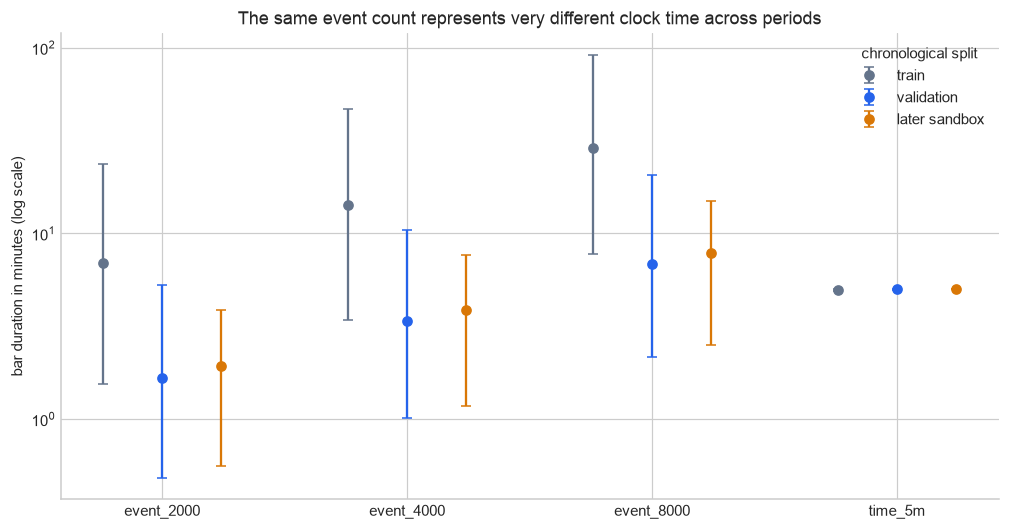

In [4]:
def ms(value):
    return int(datetime.strptime(value, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1_000)

TRAIN_END_MS, VALIDATION_END_MS = ms(TRAIN_END), ms(VALIDATION_END)

def period_expr():
    return (
        pl.when(pl.col('end_time_ms') < TRAIN_END_MS).then(pl.lit('train'))
        .when(pl.col('end_time_ms') < VALIDATION_END_MS).then(pl.lit('validation'))
        .otherwise(pl.lit('later sandbox'))
    )

duration_rows = []
for name, path in available.items():
    stats = (
        pl.scan_parquet(path).with_columns(period_expr().alias('period'))
        .group_by('period').agg(
            pl.len().alias('bars'),
            (pl.col('duration_seconds') / 60).quantile(0.10).alias('p10_minutes'),
            (pl.col('duration_seconds') / 60).median().alias('median_minutes'),
            (pl.col('duration_seconds') / 60).quantile(0.90).alias('p90_minutes'),
        ).collect()
    )
    duration_rows.extend({'construction': name, **r} for r in stats.iter_rows(named=True))
duration_summary = pl.DataFrame(duration_rows).sort('construction', 'period')
display(duration_summary)

fig, ax = plt.subplots(figsize=(11, 5.5))
names = list(available)
periods = ['train', 'validation', 'later sandbox']
width = 0.24
for j, period in enumerate(periods):
    part = duration_summary.filter(pl.col('period') == period)
    lookup = {r['construction']: r for r in part.iter_rows(named=True)}
    x = np.arange(len(names)) + (j - 1) * width
    med = np.array([lookup[n]['median_minutes'] for n in names])
    low = med - np.array([lookup[n]['p10_minutes'] for n in names])
    high = np.array([lookup[n]['p90_minutes'] for n in names]) - med
    ax.errorbar(x, med, yerr=[low, high], fmt='o', capsize=3,
                color=PERIOD_COLOURS[period], label=period)
ax.set_xticks(np.arange(len(names)), names)
ax.set_yscale('log')
ax.set_ylabel('bar duration in minutes (log scale)')
ax.set_title('The same event count represents very different clock time across periods')
ax.legend(title='chronological split')
plt.show()

## Scaling findings as a prior diagnostic

The earlier Patzelt--Bouchaud analysis used event bars from 100 to 16,000 events. Its robust scale exponents were approximately:

- characteristic normalized imbalance width: \(\xi\approx0.95\);
- characteristic response height: \(\psi\approx0.61\);
- raw signed-volume dispersion: \(H_q\approx0.63\);
- return dispersion: \(H_r\approx0.51\).

Thus doubling the event count did not merely double every quantity. The cell below reads the actual saved estimates and tests whether the 2k/4k/8k corrected-data curves look more alike after the old scaling transform. Because those estimates came from earlier academic data, the transform is a visual benchmark rather than an alpha input.

quantity,column,robust_exponent,robust_lower_95,robust_upper_95,ols_exponent,ols_r_squared
str,str,f64,f64,f64,f64,f64
"""xi: fitted response width""","""fitted_q_scale""",0.954524,0.892727,1.002027,0.958761,0.996188
"""psi: fitted response height""","""fitted_r_scale""",0.60806,0.596499,0.626061,0.61277,0.999252
"""H_q,24h: trailing-normalised s…","""trailing_volume_fraction_std""",0.629415,0.61576,0.638856,0.627644,0.999842
"""H_q,raw: signed BTC volume""","""signed_volume_std""",0.628326,0.613649,0.638024,0.62557,0.999804
"""H_epsilon: order signs""","""sign_sum_std""",0.763641,0.754425,0.769209,0.76256,0.999951
"""H_r: returns""","""return_std""",0.507316,0.496585,0.51305,0.50781,0.999687


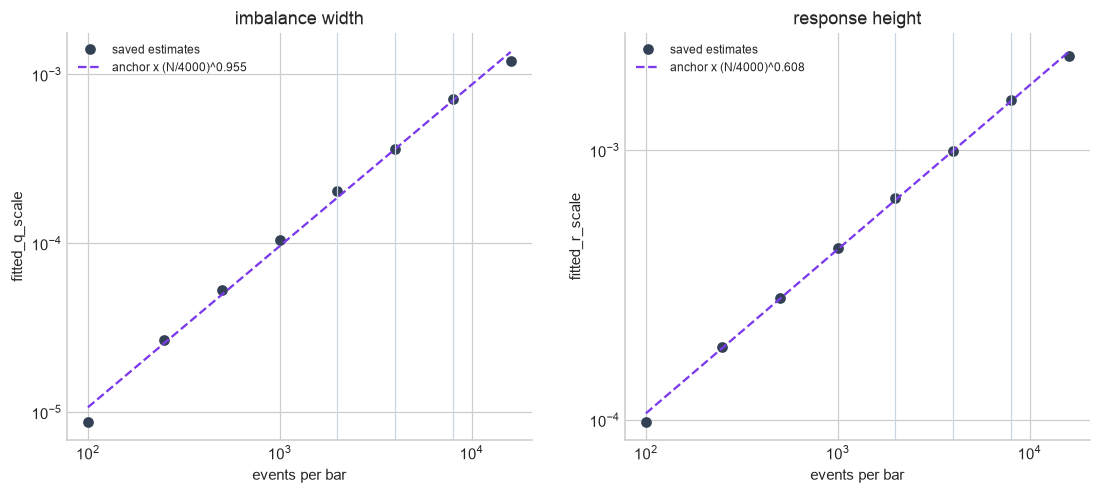

In [5]:
PB_TABLES = ACADEMIC / 'reports' / 'tables'
pb_scales = pl.read_csv(PB_TABLES / 'pb_scale_estimates.csv')
pb_exponents = pl.read_csv(PB_TABLES / 'pb_scaling_exponents.csv')
display(pb_exponents)

xi = float(pb_exponents.filter(pl.col('column') == 'fitted_q_scale')['robust_exponent'][0])
psi = float(pb_exponents.filter(pl.col('column') == 'fitted_r_scale')['robust_exponent'][0])
n = pb_scales['n_events'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, column, exponent, title in [
    (axes[0], 'fitted_q_scale', xi, 'imbalance width'),
    (axes[1], 'fitted_r_scale', psi, 'response height'),
]:
    values = pb_scales[column].to_numpy()
    anchor_n = 4_000
    anchor_value = float(pb_scales.filter(pl.col('n_events') == 4_000)[column][0])
    grid = np.geomspace(n.min(), n.max(), 200)
    ax.loglog(n, values, 'o', color='#334155', label='saved estimates')
    ax.loglog(grid, anchor_value * (grid / anchor_n) ** exponent, '--', color='#7c3aed',
              label=f'anchor x (N/4000)^{exponent:.3f}')
    for chosen in (2_000, 4_000, 8_000):
        ax.axvline(chosen, color='#cbd5e1', lw=0.8)
    ax.set_xlabel('events per bar')
    ax.set_ylabel(column)
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.show()

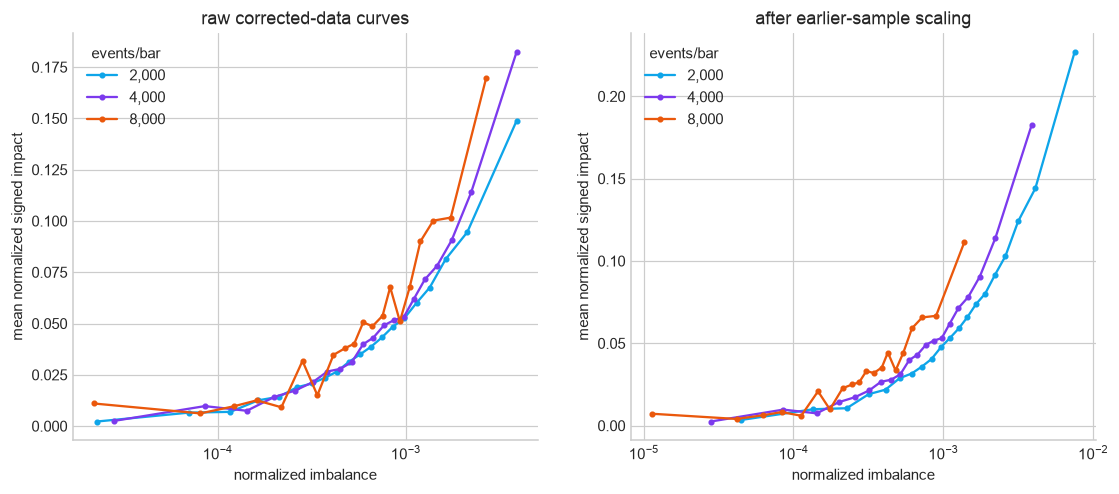

In [6]:
def binned_xy(x, y, bins=20, edges=None):
    x, y = np.asarray(x, float), np.asarray(y, float)
    keep = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x, y = x[keep], y[keep]
    if edges is None:
        edges = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    ids = np.digitize(x, edges[1:-1], right=True)
    rows = []
    for i in range(len(edges) - 1):
        chosen = ids == i
        if chosen.sum() < 3:
            continue
        rows.append((x[chosen].mean(), y[chosen].mean(),
                     y[chosen].std(ddof=1) / math.sqrt(chosen.sum()), chosen.sum()))
    return np.asarray(rows), edges

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for size, colour in zip((2_000, 4_000, 8_000), ('#0ea5e9', '#7c3aed', '#ea580c')):
    path = CACHE_PATHS[f'event_{size}']
    sample = (pl.scan_parquet(path).filter(pl.col('end_time_ms') < TRAIN_END_MS)
              .select('normalised_imbalance', 'normalised_signed_impact').drop_nulls().collect())
    x = sample['normalised_imbalance'].to_numpy()
    y = sample['normalised_signed_impact'].to_numpy()
    raw, _ = binned_xy(x, y, CURVE_BINS)
    size_ratio = size / 4_000
    scaled, _ = binned_xy(x / size_ratio ** xi, y / size_ratio ** psi, CURVE_BINS)
    axes[0].plot(raw[:, 0], raw[:, 1], 'o-', ms=3, color=colour, label=f'{size:,}')
    axes[1].plot(scaled[:, 0], scaled[:, 1], 'o-', ms=3, color=colour, label=f'{size:,}')
for ax, title in zip(axes, ('raw corrected-data curves', 'after earlier-sample scaling')):
    ax.set_xscale('log')
    ax.set_xlabel('normalized imbalance')
    ax.set_ylabel('mean normalized signed impact')
    ax.set_title(title)
    ax.legend(title='events/bar')
plt.show()

## Load the selected construction

In [7]:
construction = f'event_{EVENTS_PER_BAR}' if BAR_KIND == 'event' else f'time_{TIME_BAR_SIZE}'
selected_path = CACHE_ROOT / construction / 'part-000.parquet'

if not selected_path.exists():
    if not BUILD_MISSING_CACHE:
        raise FileNotFoundError(
            f'{selected_path} is not cached. Choose 2000/4000/8000, or set BUILD_MISSING_CACHE=True.'
        )
    reports = sorted((SHARED / 'metadata' / 'BTCUSDT').glob('????-??.json'))
    event_paths = []
    for report in reports:
        year, month = report.stem.split('-')
        path = (SHARED / 'events' / 'timestamp_direction_v1' / 'symbol=BTCUSDT'
                / f'year={year}' / f'month={month}' / 'part-000.parquet')
        if path.exists():
            event_paths.append(path)
    events = pl.scan_parquet(event_paths)
    if BAR_KIND == 'event':
        selected = build_fixed_event_bars(events, events_per_bar=EVENTS_PER_BAR, assume_ordered=True)
    else:
        selected = build_time_bars(events, every=TIME_BAR_SIZE, assume_ordered=True)
    selected = add_trailing_impact_features(
        add_bar_horizon_targets(selected, horizons=range(1, 13)), window='1d'
    )
    selected_path.parent.mkdir(parents=True, exist_ok=True)
    selected.sink_parquet(selected_path, compression='zstd', compression_level=6)

bars = pl.read_parquet(selected_path).with_columns(period_expr().alias('period'))
print(f'{construction}: {bars.height:,} bars, {bars.width} columns')

event_4000: 173,687 bars, 53 columns


## Statistical summary of the selected data

In [8]:
data_summary = (
    bars.group_by('period').agg(
        pl.len().alias('bars'),
        pl.from_epoch('end_time_ms', time_unit='ms').dt.date().n_unique().alias('utc_days'),
        (pl.col('duration_seconds').median() / 60).alias('median_duration_min'),
        (pl.col('duration_seconds').quantile(0.10) / 60).alias('duration_p10_min'),
        (pl.col('duration_seconds').quantile(0.90) / 60).alias('duration_p90_min'),
        pl.col('event_count').median().alias('median_events'),
        pl.col('gross_volume').median().alias('median_volume_btc'),
        pl.col('absolute_imbalance_ratio').median().alias('median_abs_imbalance_ratio'),
        pl.col('current_return_bps').std().alias('return_std_bps'),
        pl.col('normalised_imbalance').median().alias('median_x'),
        pl.col('normalised_signed_impact').mean().alias('mean_y'),
        (pl.col('signed_imbalance') > 0).mean().alias('buy_dominated_share'),
        pl.col('normalised_imbalance').is_not_null().mean().alias('usable_normalised_share'),
    ).sort('period')
)
display(data_summary)

dictionary = pl.DataFrame({
    'field': ['signed_imbalance', 'current_return_bps', 'normalised_imbalance',
              'normalised_signed_impact', f'future_return_{FUTURE_HORIZON}_bps'],
    'definition': [
        'sum(aggressor_sign x BTC quantity) inside the current bar',
        '10,000 x log(last price / first price) inside the current bar',
        '|signed imbalance| / preceding-24h gross volume',
        'sign(imbalance) x current return / preceding-24h realised volatility',
        f'10,000 x log(close[n+{FUTURE_HORIZON}] / close[n]); prediction target',
    ],
    'available_at_bar_close': [True, True, True, True, False],
})
display(dictionary)

period,bars,utc_days,median_duration_min,duration_p10_min,duration_p90_min,median_events,median_volume_btc,median_abs_imbalance_ratio,return_std_bps,median_x,mean_y,buy_dominated_share,usable_normalised_share
str,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""later sandbox""",62772,184,3.8831,1.181217,7.632583,4000.0,976.4005,0.150339,19.964663,0.000374,0.034772,0.488211,1.0
"""train""",23867,358,14.1844,3.4323,46.517583,4000.0,3047.641,0.094705,50.004718,0.000632,0.049672,0.497884,0.441698
"""validation""",87048,303,3.385625,1.01895,10.460467,4000.0,1116.2725,0.130459,30.807531,0.000304,0.034897,0.487019,0.956426


field,definition,available_at_bar_close
str,str,bool
"""signed_imbalance""","""sum(aggressor_sign x BTC quant…",true
"""current_return_bps""","""10,000 x log(last price / firs…",true
"""normalised_imbalance""","""|signed imbalance| / preceding…",true
"""normalised_signed_impact""","""sign(imbalance) x current retu…",true
"""future_return_5_bps""","""10,000 x log(close[n+5] / clos…",false


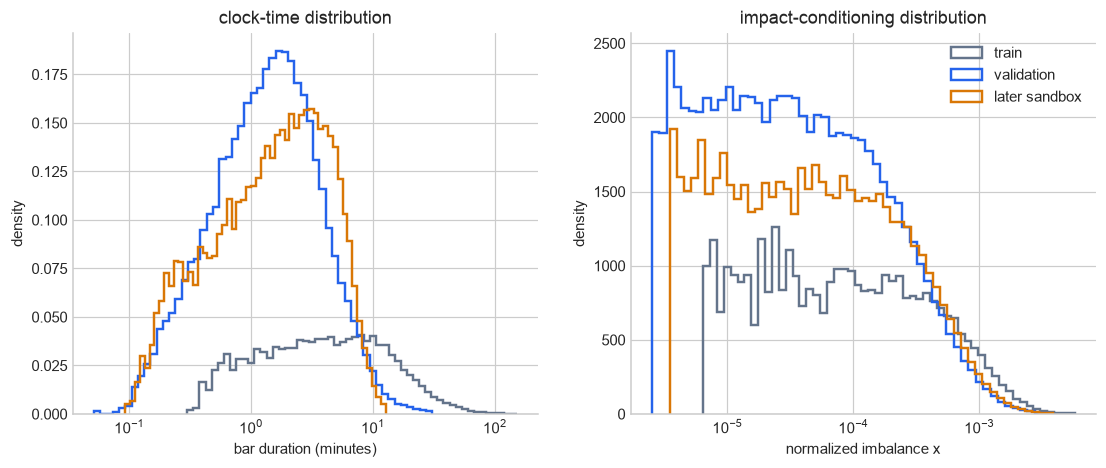

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for period in ['train', 'validation', 'later sandbox']:
    part = bars.filter(pl.col('period') == period)
    duration = (part['duration_seconds'] / 60).to_numpy()
    x = part['normalised_imbalance'].drop_nulls().to_numpy()
    axes[0].hist(duration[np.isfinite(duration)],
                 bins=np.geomspace(max(duration.min(), 0.01), np.quantile(duration, .995), 55),
                 density=True, histtype='step', lw=1.6, color=PERIOD_COLOURS[period], label=period)
    positive = x[(x > 0) & np.isfinite(x)]
    axes[1].hist(positive, bins=np.geomspace(np.quantile(positive, .005),
                 np.quantile(positive, .995), 55), density=True, histtype='step', lw=1.6,
                 color=PERIOD_COLOURS[period], label=period)
axes[0].set_xscale('log')
axes[0].set_xlabel('bar duration (minutes)')
axes[0].set_ylabel('density')
axes[1].set_xscale('log')
axes[1].set_xlabel('normalized imbalance x')
axes[1].set_ylabel('density')
axes[0].set_title('clock-time distribution')
axes[1].set_title('impact-conditioning distribution')
axes[1].legend()
plt.show()

## The exact fitted impact model

The default model is fitted on training bars only. With separate sides it is

\[
\widehat y_t =
\begin{cases}
a_B+b_B\log(1+x_t/x_0), & Q_t>0,\\
a_S+b_S\log(1+x_t/x_0), & Q_t<0,
\end{cases}
\]

where \(x_0\) is the median training-sample \(x_t\), shared by both sides. SIDE_MODE = pooled imposes \(a_B=a_S\) and \(b_B=b_S\). The linear choice replaces the log term with \(x/x_0\); power uses \((x/x_0)^\delta\) with the displayed POWER_EXPONENT.

The default FIT_SAMPLE = raw_bars is ordinary least squares over individual bars and matches the current alpha helper exactly. bin_means instead forms equal-count bins on each side and fits conditional means with inverse-variance weights, closer to the academic functional-form comparison.

This is still a **contemporaneous** model. It becomes an alpha experiment only in the later cells, where frozen training coefficients create features that are compared with future returns.

In [10]:
def transform_x(x, family, x0, delta):
    ratio = np.asarray(x, float) / x0
    if family == 'log':
        return np.log1p(ratio)
    if family == 'linear':
        return ratio
    return ratio ** delta

def weighted_line(z, y, weights, include_intercept=True):
    X = np.column_stack([np.ones(len(z)), z]) if include_intercept else z[:, None]
    root_w = np.sqrt(weights)
    coef = np.linalg.lstsq(X * root_w[:, None], y * root_w, rcond=None)[0]
    if include_intercept:
        intercept, slope = map(float, coef)
    else:
        intercept, slope = 0.0, float(coef[0])
    fitted = intercept + slope * z
    mean_y = np.average(y, weights=weights)
    sse = np.sum(weights * (y - fitted) ** 2)
    sst = np.sum(weights * (y - mean_y) ** 2)
    return intercept, slope, 1 - sse / sst

def fit_observations(x, y, bins):
    if FIT_SAMPLE == 'raw_bars':
        return x, y, np.ones(len(x)), len(x)
    curve, _ = binned_xy(x, y, bins)
    bx, by, se, count = curve.T
    weights = np.where(se > 0, 1 / se ** 2, count)
    return bx, by, weights, int(count.sum())

training = bars.filter(pl.col('period') == 'train').select(
    'normalised_imbalance', 'normalised_signed_impact', 'signed_imbalance'
).drop_nulls()
x_train = training['normalised_imbalance'].to_numpy()
y_train = training['normalised_signed_impact'].to_numpy()
side_train = np.sign(training['signed_imbalance'].to_numpy()).astype(int)
valid = np.isfinite(x_train) & np.isfinite(y_train) & (x_train > 0) & (side_train != 0)
x_train, y_train, side_train = x_train[valid], y_train[valid], side_train[valid]
x0 = float(np.median(x_train))

fit_rows = []
groups = [('buy', 1), ('sell', -1)] if SIDE_MODE == 'separate' else [('pooled', 0)]
for label, side_value in groups:
    chosen = np.ones(len(x_train), dtype=bool) if side_value == 0 else side_train == side_value
    fx, fy, weights, observations = fit_observations(x_train[chosen], y_train[chosen], CURVE_BINS)
    z = transform_x(fx, MODEL_FAMILY, x0, POWER_EXPONENT)
    intercept, slope, r2 = weighted_line(z, fy, weights, INCLUDE_INTERCEPT)
    fit_rows.append({'side': label, 'observations': observations, 'intercept': intercept,
                     'slope': slope, 'r_squared': r2})

fit_table = pl.DataFrame(fit_rows)
display(fit_table)
print(f'common training x0 = {x0:.8g}; model family = {MODEL_FAMILY}; fit sample = {FIT_SAMPLE}')
for row in fit_rows:
    print(f"{row['side']:>6}: y_hat = {row['intercept']:.6f} + {row['slope']:.6f} x {MODEL_FAMILY}_basis(x/x0)")

if MODEL_FAMILY == 'log' and SIDE_MODE == 'separate' and FIT_SAMPLE == 'raw_bars' and INCLUDE_INTERCEPT:
    hidden_fit = fit_asymmetric_log_impact(bars.filter(pl.col('period') == 'train').lazy())
    check = pl.DataFrame({
        'coefficient': ['buy intercept', 'buy slope', 'sell intercept', 'sell slope', 'x0'],
        'workbench': [fit_rows[0]['intercept'], fit_rows[0]['slope'], fit_rows[1]['intercept'],
                      fit_rows[1]['slope'], x0],
        'existing helper': [hidden_fit.buy.intercept, hidden_fit.buy.slope, hidden_fit.sell.intercept,
                            hidden_fit.sell.slope, hidden_fit.imbalance_scale],
    }).with_columns((pl.col('workbench') - pl.col('existing helper')).abs().alias('absolute_difference'))
    display(Markdown('**Audit check:** the visible calculation below reproduces the existing helper.'))
    display(check)

side,observations,intercept,slope,r_squared
str,i64,f64,f64,f64
"""buy""",5671,-0.015025,0.08034,0.345728
"""sell""",4871,-0.016325,0.094394,0.391738


common training x0 = 0.00063188189; model family = log; fit sample = raw_bars
   buy: y_hat = -0.015025 + 0.080340 x log_basis(x/x0)
  sell: y_hat = -0.016325 + 0.094394 x log_basis(x/x0)


**Audit check:** the visible calculation below reproduces the existing helper.

coefficient,workbench,existing helper,absolute_difference
str,f64,f64,f64
"""buy intercept""",-0.015025,-0.015025,1.7347e-17
"""buy slope""",0.08034,0.08034,6.9389e-17
"""sell intercept""",-0.016325,-0.016325,4.1633e-17
"""sell slope""",0.094394,0.094394,2.7756e-17
"""x0""",0.000632,0.000632,0.0


In [11]:
params = {r['side']: r for r in fit_rows}
x_all = bars['normalised_imbalance'].to_numpy()
y_all = bars['normalised_signed_impact'].to_numpy()
side_all = np.sign(bars['signed_imbalance'].to_numpy()).astype(int)
expected = np.full(len(bars), np.nan)
dy_dx = np.full(len(bars), np.nan)

for label, side_value in ([('buy', 1), ('sell', -1)] if SIDE_MODE == 'separate' else [('pooled', 0)]):
    chosen = (side_all == side_value) if side_value else (side_all != 0)
    valid_x = chosen & np.isfinite(x_all) & (x_all > 0)
    p = params[label]
    expected[valid_x] = p['intercept'] + p['slope'] * transform_x(
        x_all[valid_x], MODEL_FAMILY, x0, POWER_EXPONENT)
    if MODEL_FAMILY == 'log':
        dy_dx[valid_x] = p['slope'] / (x0 + x_all[valid_x])
    elif MODEL_FAMILY == 'linear':
        dy_dx[valid_x] = p['slope'] / x0
    else:
        dy_dx[valid_x] = (p['slope'] * POWER_EXPONENT / x0
                          * (x_all[valid_x] / x0) ** (POWER_EXPONENT - 1))

volume = bars['trailing_market_volume'].to_numpy()
volatility = bars['trailing_realised_volatility_bps'].to_numpy()
marginal = volatility * dy_dx / volume
bars = bars.with_columns(
    pl.Series('expected_normalised_impact', expected),
    pl.Series('impact_residual', y_all - expected),
    pl.Series('marginal_impact_bps_per_btc', marginal),
)

## See the fitted buy and sell curves

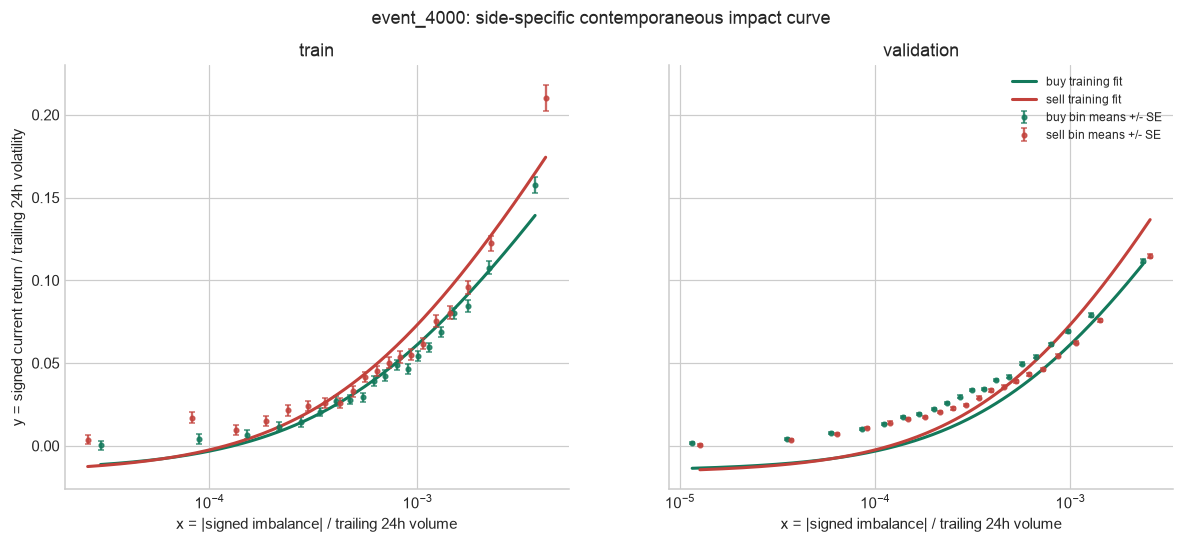

In [12]:
def side_curve(frame, side_value, bins=CURVE_BINS, edges=None):
    part = frame.filter(pl.col('signed_imbalance').sign() == side_value).select(
        'normalised_imbalance', 'normalised_signed_impact').drop_nulls()
    return binned_xy(part['normalised_imbalance'].to_numpy(),
                     part['normalised_signed_impact'].to_numpy(), bins, edges)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, period in zip(axes, ['train', 'validation']):
    part = bars.filter(pl.col('period') == period)
    for label, side_value, colour in [('buy', 1, BUY_COLOUR), ('sell', -1, SELL_COLOUR)]:
        curve, _ = side_curve(part, side_value)
        ax.errorbar(curve[:, 0], curve[:, 1], yerr=curve[:, 2], fmt='o', ms=3, capsize=2,
                    color=colour, alpha=.8, label=f'{label} bin means +/- SE')
        x_grid = np.geomspace(curve[:, 0].min(), curve[:, 0].max(), 200)
        p = params[label] if SIDE_MODE == 'separate' else params['pooled']
        y_grid = p['intercept'] + p['slope'] * transform_x(x_grid, MODEL_FAMILY, x0, POWER_EXPONENT)
        ax.plot(x_grid, y_grid, color=colour, lw=2, label=f'{label} training fit')
    ax.set_xscale('log')
    ax.set_xlabel('x = |signed imbalance| / trailing 24h volume')
    ax.set_title(period)
axes[0].set_ylabel('y = signed current return / trailing 24h volatility')
axes[1].legend(fontsize=8)
fig.suptitle(f'{construction}: side-specific contemporaneous impact curve')
plt.show()

## Symmetry diagnostic

The folded academic curve assumes that buy- and sell-dominated bars have the same response after returns are aligned with imbalance direction. Here both sides use identical training-derived x-bin edges, so vertical gaps are actual asymmetry rather than different bin support. The gap is descriptive; a large sample can make a small economic difference statistically visible.

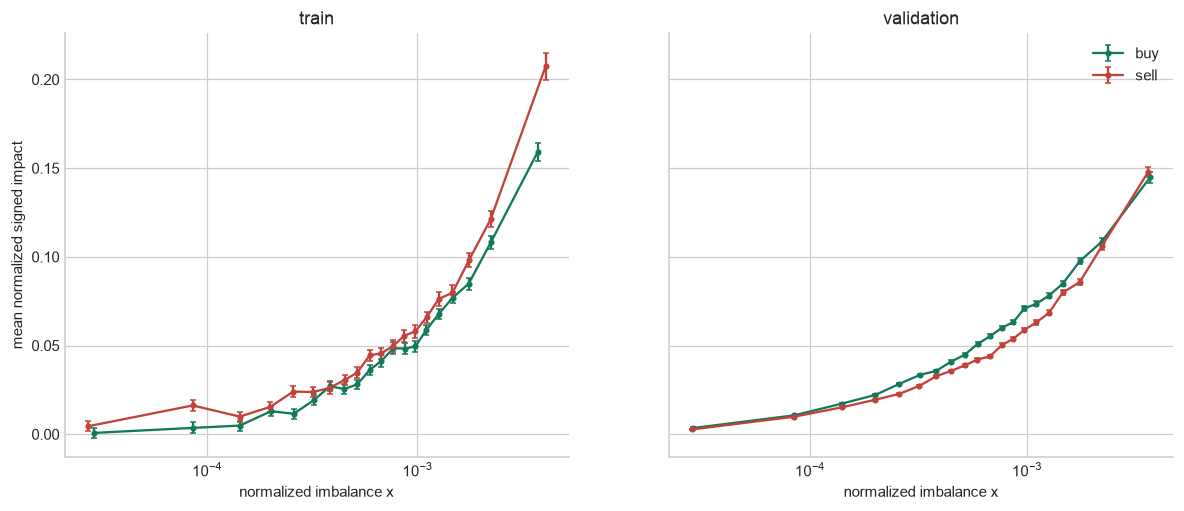

period,mean_bin_gap_buy_minus_sell,rms_bin_gap,last_bin_gap
str,f64,f64,f64
"""train""",-0.008747,0.013244,-0.048571
"""validation""",0.00602,0.007332,-0.002899


In [13]:
combined_train_x = bars.filter(pl.col('period') == 'train')['normalised_imbalance'].drop_nulls().to_numpy()
common_edges = np.unique(np.quantile(combined_train_x[combined_train_x > 0],
                                     np.linspace(0, 1, CURVE_BINS + 1)))
symmetry_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, period in zip(axes, ['train', 'validation']):
    curves = {}
    for label, side_value, colour in [('buy', 1, BUY_COLOUR), ('sell', -1, SELL_COLOUR)]:
        curve, _ = side_curve(bars.filter(pl.col('period') == period), side_value, edges=common_edges)
        curves[label] = curve
        ax.errorbar(curve[:, 0], curve[:, 1], yerr=curve[:, 2], fmt='o-', ms=3,
                    capsize=2, color=colour, label=label)
    count = min(len(curves['buy']), len(curves['sell']))
    gap = curves['buy'][:count, 1] - curves['sell'][:count, 1]
    symmetry_rows.append({'period': period, 'mean_bin_gap_buy_minus_sell': float(gap.mean()),
                          'rms_bin_gap': float(np.sqrt(np.mean(gap ** 2))),
                          'last_bin_gap': float(gap[-1])})
    ax.set_xscale('log')
    ax.set_xlabel('normalized imbalance x')
    ax.set_title(period)
axes[0].set_ylabel('mean normalized signed impact')
axes[1].legend()
plt.show()
display(pl.DataFrame(symmetry_rows))

## Residual and marginal-impact diagnostics

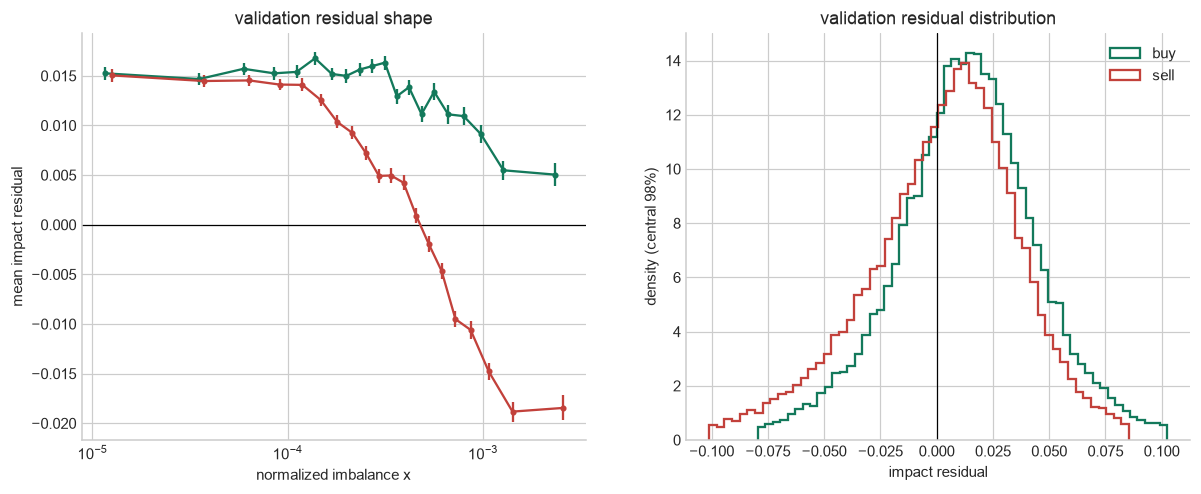

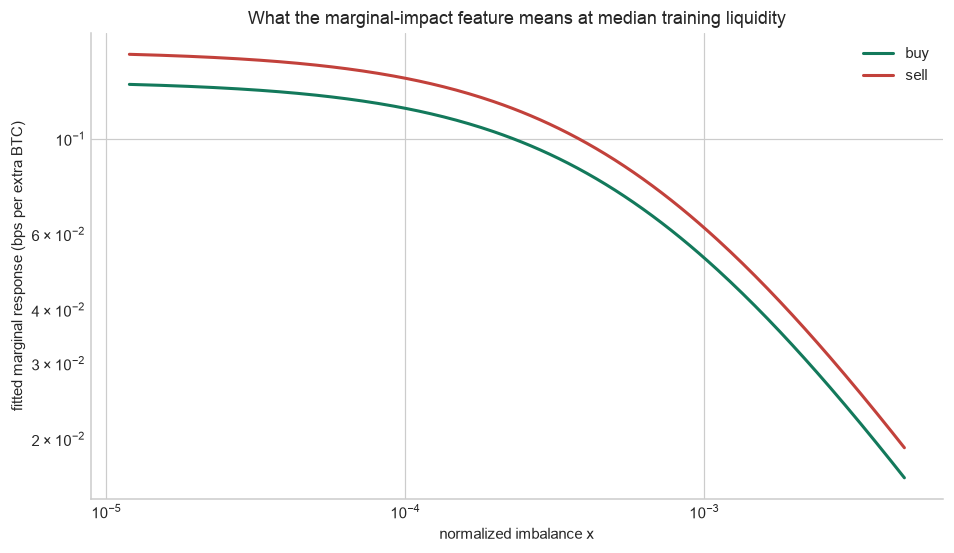

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
validation = bars.filter(pl.col('period') == 'validation')
for label, side_value, colour in [('buy', 1, BUY_COLOUR), ('sell', -1, SELL_COLOUR)]:
    part = validation.filter(pl.col('signed_imbalance').sign() == side_value).select(
        'normalised_imbalance', 'impact_residual').drop_nulls()
    curve, _ = binned_xy(part['normalised_imbalance'].to_numpy(),
                         part['impact_residual'].to_numpy(), CURVE_BINS)
    axes[0].errorbar(curve[:, 0], curve[:, 1], yerr=curve[:, 2], fmt='o-', ms=3,
                     color=colour, label=label)
    residual = part['impact_residual'].to_numpy()
    lo, hi = np.quantile(residual, [.01, .99])
    axes[1].hist(residual[(residual >= lo) & (residual <= hi)], bins=55, density=True,
                 histtype='step', lw=1.5, color=colour, label=label)
axes[0].axhline(0, color='black', lw=.8)
axes[0].set_xscale('log')
axes[0].set_xlabel('normalized imbalance x')
axes[0].set_ylabel('mean impact residual')
axes[0].set_title('validation residual shape')
axes[1].axvline(0, color='black', lw=.8)
axes[1].set_xlabel('impact residual')
axes[1].set_ylabel('density (central 98%)')
axes[1].set_title('validation residual distribution')
axes[1].legend()
plt.show()

representative = bars.filter(pl.col('period') == 'train').select(
    pl.col('trailing_market_volume').median(),
    pl.col('trailing_realised_volatility_bps').median(),
).row(0)
x_grid = np.geomspace(np.nanquantile(x_train, .01), np.nanquantile(x_train, .99), 250)
fig, ax = plt.subplots()
for label, colour in [('buy', BUY_COLOUR), ('sell', SELL_COLOUR)]:
    p = params[label] if SIDE_MODE == 'separate' else params['pooled']
    if MODEL_FAMILY == 'log':
        derivative = p['slope'] / (x0 + x_grid)
    elif MODEL_FAMILY == 'linear':
        derivative = np.repeat(p['slope'] / x0, len(x_grid))
    else:
        derivative = p['slope'] * POWER_EXPONENT / x0 * (x_grid / x0) ** (POWER_EXPONENT - 1)
    ax.plot(x_grid, representative[1] * derivative / representative[0],
            color=colour, lw=2, label=label)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('normalized imbalance x')
ax.set_ylabel('fitted marginal response (bps per extra BTC)')
ax.set_title('What the marginal-impact feature means at median training liquidity')
ax.legend()
plt.show()

## Choose the prediction horizon in event time and clock time

The prediction target is

\[
R_{t,h}=10^4\log(P_{t+h}/P_t),
\]

measured from the current bar close to the future bar close. Event horizon h=5 means n+5, not five minutes. The graph below shows the realized clock-time distribution, so the chosen event horizon can be interpreted rather than guessed. The shaded strip is the desired 15--30 minute region.

period,horizon,p10_minutes,median_minutes,p90_minutes
str,i64,f64,f64,f64
"""train""",5,22.904217,74.428333,222.9337
"""validation""",5,5.926817,17.483892,50.3789
"""later sandbox""",5,7.093433,19.896667,36.4589


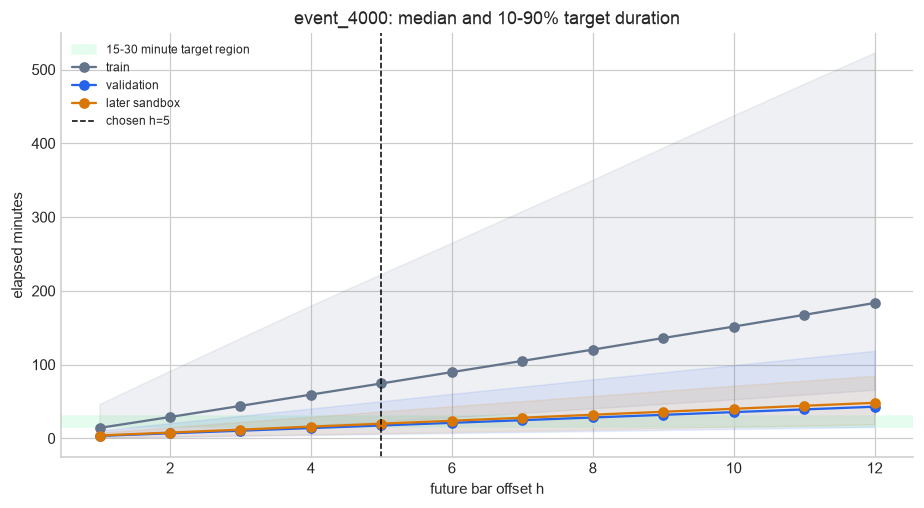

In [15]:
available_horizons = sorted(int(m.group(1)) for c in bars.columns
                            if (m := re.fullmatch(r'future_elapsed_(\d+)_minutes', c)))
horizon_rows = []
for period in ['train', 'validation', 'later sandbox']:
    part = bars.filter(pl.col('period') == period)
    for h in available_horizons:
        col = f'future_elapsed_{h}_minutes'
        row = part.select(
            pl.col(col).quantile(.1).alias('p10'),
            pl.col(col).median().alias('median'),
            pl.col(col).quantile(.9).alias('p90'),
        ).row(0)
        horizon_rows.append({'period': period, 'horizon': h, 'p10_minutes': row[0],
                             'median_minutes': row[1], 'p90_minutes': row[2]})
horizon_summary = pl.DataFrame(horizon_rows)
display(horizon_summary.filter(pl.col('horizon') == FUTURE_HORIZON))

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhspan(*TARGET_MINUTES, color='#dcfce7', alpha=.7, label='15-30 minute target region')
for period in ['train', 'validation', 'later sandbox']:
    part = horizon_summary.filter(pl.col('period') == period).sort('horizon')
    h = part['horizon'].to_numpy()
    med = part['median_minutes'].to_numpy()
    ax.plot(h, med, 'o-', color=PERIOD_COLOURS[period], label=period)
    ax.fill_between(h, part['p10_minutes'].to_numpy(), part['p90_minutes'].to_numpy(),
                    color=PERIOD_COLOURS[period], alpha=.10)
ax.axvline(FUTURE_HORIZON, color='black', ls='--', lw=1, label=f'chosen h={FUTURE_HORIZON}')
ax.set_xlabel('future bar offset h')
ax.set_ylabel('elapsed minutes')
ax.set_title(f'{construction}: median and 10-90% target duration')
ax.legend(fontsize=8)
plt.show()

## Alpha view: do present impact features predict a future return?

Quintile cut points are estimated separately for buy- and sell-dominated bars using the training period, then frozen. Future returns are aligned with the current imbalance direction: positive means continuation and negative means reversal. Error bars below are ordinary standard errors and understate uncertainty when horizons overlap; day/week block inference belongs in the formal walk-forward stage.

The dotted cost line is only a visual hurdle. These conditional returns are not yet a trading strategy because entry price, position rule, turnover, spread, fees and slippage still need to be specified.

period,side,feature_quintile,observations,mean_feature,mean_aligned_return_bps,return_std_bps,naive_standard_error
str,f64,i8,u32,f64,f64,f64,f64
"""later sandbox""",-1.0,1,3845,-0.068595,-1.437312,46.117422,0.743733
"""later sandbox""",-1.0,2,7095,-0.025458,-1.259092,42.130806,0.500177
"""later sandbox""",-1.0,3,9017,-0.001136,-0.302097,41.91216,0.441376
"""later sandbox""",-1.0,4,8704,0.022823,-1.036355,43.687231,0.468269
"""later sandbox""",-1.0,5,3463,0.057923,-2.350712,53.494291,0.909036
…,…,…,…,…,…,…,…
"""validation""",1.0,1,2416,-0.062204,1.840108,63.8506,1.299022
"""validation""",1.0,2,5451,-0.02367,0.378801,62.944303,0.852547
"""validation""",1.0,3,11012,0.000537,-0.302182,64.297952,0.612723


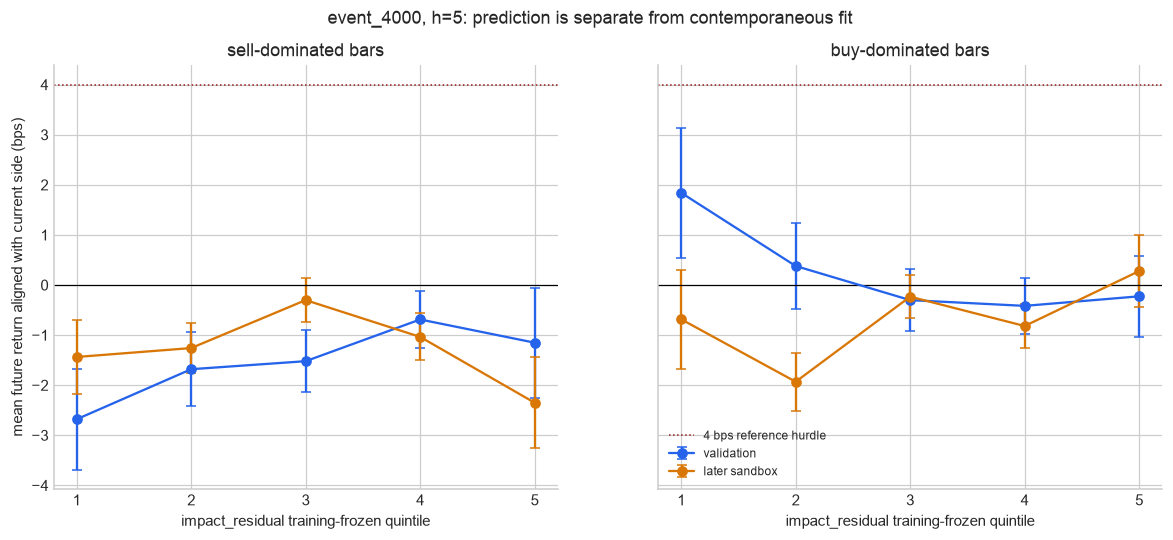

In [16]:
target_col = f'future_return_{FUTURE_HORIZON}_bps'
if target_col not in bars.columns:
    raise ValueError(f'{target_col} is not available in this cache; choose one of {available_horizons}.')

cut_points = {}
for side_value in (-1, 1):
    values = bars.filter(
        (pl.col('period') == 'train') &
        (pl.col('signed_imbalance').sign() == side_value) &
        pl.col(ALPHA_FEATURE).is_finite()
    )[ALPHA_FEATURE].to_numpy()
    cut_points[side_value] = np.quantile(values, [.2, .4, .6, .8])

feature = bars[ALPHA_FEATURE].to_numpy()
side = np.sign(bars['signed_imbalance'].to_numpy()).astype(int)
target = bars[target_col].to_numpy()
quintile = np.full(len(bars), 0, dtype=np.int8)
for side_value in (-1, 1):
    chosen = (side == side_value) & np.isfinite(feature)
    quintile[chosen] = np.digitize(feature[chosen], cut_points[side_value], right=True) + 1

alpha_frame = bars.with_columns(
    pl.Series('feature_quintile', quintile),
    pl.Series('aligned_future_return_bps', side * target),
).filter(
    (pl.col('feature_quintile') > 0) &
    pl.col('aligned_future_return_bps').is_finite()
)

alpha_summary = (
    alpha_frame.group_by('period', pl.col('signed_imbalance').sign().alias('side'),
                         'feature_quintile')
    .agg(
        pl.len().alias('observations'),
        pl.col(ALPHA_FEATURE).mean().alias('mean_feature'),
        pl.col('aligned_future_return_bps').mean().alias('mean_aligned_return_bps'),
        pl.col('aligned_future_return_bps').std().alias('return_std_bps'),
    )
    .with_columns((pl.col('return_std_bps') / pl.col('observations').sqrt()).alias('naive_standard_error'))
    .sort('period', 'side', 'feature_quintile')
)
display(alpha_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (side_value, label) in zip(axes, [(-1, 'sell-dominated bars'), (1, 'buy-dominated bars')]):
    for period in ['validation', 'later sandbox']:
        part = alpha_summary.filter((pl.col('side') == side_value) & (pl.col('period') == period))
        ax.errorbar(part['feature_quintile'].to_numpy(),
                    part['mean_aligned_return_bps'].to_numpy(),
                    yerr=part['naive_standard_error'].to_numpy(),
                    fmt='o-', capsize=3, color=PERIOD_COLOURS[period], label=period)
    ax.axhline(0, color='black', lw=.8)
    ax.axhline(REFERENCE_COST_BPS, color='#991b1b', ls=':', lw=1,
               label=f'{REFERENCE_COST_BPS:g} bps reference hurdle')
    ax.set_xticks(range(1, 6))
    ax.set_xlabel(f'{ALPHA_FEATURE} training-frozen quintile')
    ax.set_title(label)
axes[0].set_ylabel('mean future return aligned with current side (bps)')
axes[1].legend(fontsize=8)
fig.suptitle(f'{construction}, h={FUTURE_HORIZON}: prediction is separate from contemporaneous fit')
plt.show()

## Event-bar versus time-bar sandbox comparison already run

construction,reference_4000_horizon,nominal_time_minutes,horizon_bars,period,feature,side,days,q5_minus_q1_aligned_return_bps,day_block_t_stat
str,i64,i64,i64,str,str,str,i64,f64,f64
"""event_2000""",3,15,6,"""sandbox_test""","""impact_residual""","""buy""",184,1.733078,2.060831
"""event_4000""",3,15,3,"""sandbox_test""","""impact_residual""","""buy""",184,1.891414,1.868088
"""event_8000""",3,15,2,"""sandbox_test""","""impact_residual""","""buy""",181,-0.102319,-0.092028
"""time_5m""",3,15,3,"""sandbox_test""","""impact_residual""","""buy""",184,0.748756,0.966858
"""event_2000""",4,20,8,"""sandbox_test""","""impact_residual""","""buy""",184,1.423927,1.485385
…,…,…,…,…,…,…,…,…,…
"""time_5m""",5,25,5,"""validation""","""impact_residual""","""sell""",302,-4.042557,-2.544564
"""event_2000""",6,30,12,"""validation""","""impact_residual""","""sell""",301,-3.275505,-2.156284
"""event_4000""",6,30,6,"""validation""","""impact_residual""","""sell""",253,-1.975434,-0.890764


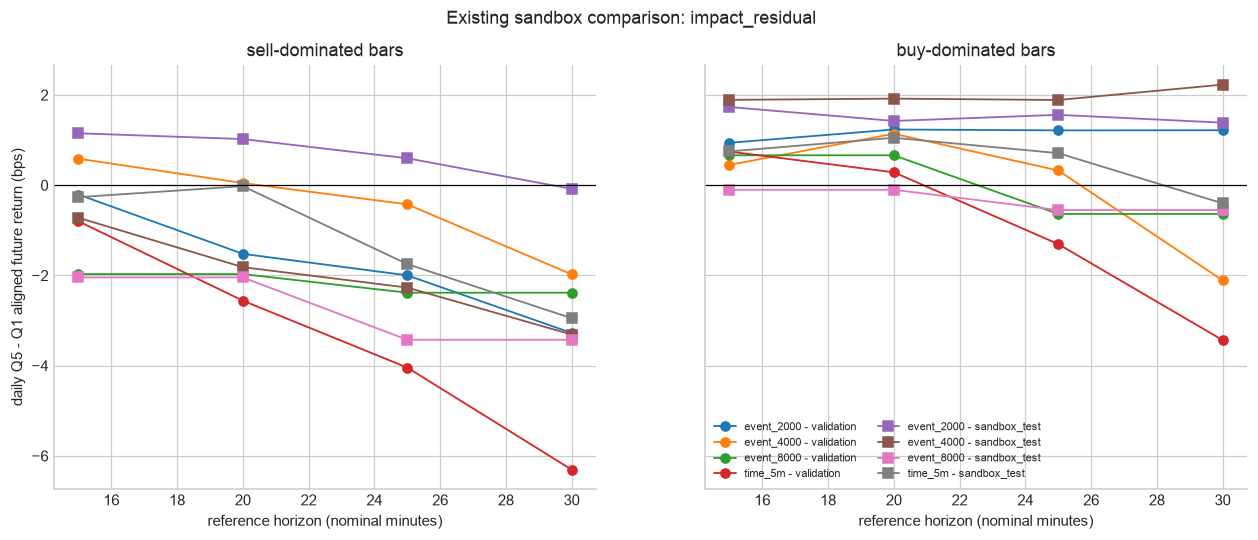

In [17]:
result_path = ALPHA / 'reports' / 'tables' / 'impact_alpha_v1_extreme_contrasts.csv'
contrasts = pl.read_csv(result_path).filter(pl.col('feature') == ALPHA_FEATURE)
display(contrasts.sort('period', 'side', 'reference_4000_horizon', 'construction'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, side_label in zip(axes, ['sell', 'buy']):
    part = contrasts.filter(pl.col('side') == side_label)
    labels = sorted(part['construction'].unique().to_list())
    for period, marker in [('validation', 'o'), ('sandbox_test', 's')]:
        for name in labels:
            line = part.filter(
                (pl.col('period') == period) &
                (pl.col('construction') == name)
            ).sort('nominal_time_minutes')
            ax.plot(line['nominal_time_minutes'].to_numpy(),
                    line['q5_minus_q1_aligned_return_bps'].to_numpy(),
                    marker=marker, lw=1.2, label=f'{name} - {period}')
    ax.axhline(0, color='black', lw=.8)
    ax.set_xlabel('reference horizon (nominal minutes)')
    ax.set_title(f'{side_label}-dominated bars')
axes[0].set_ylabel('daily Q5 - Q1 aligned future return (bps)')
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle(f'Existing sandbox comparison: {ALPHA_FEATURE}')
plt.show()

## Reading the output without turning it into a black box

1. **Start with duration.** A fixed event horizon changes clock-time meaning when activity changes. Choose FUTURE_HORIZON only after reading the duration plot.
2. **Inspect the impact graph.** If buy and sell bin means differ materially, a pooled/folded model hides information. If fitted lines miss curvature, residual alpha may merely be model misspecification.
3. **Inspect drift and support.** A validation relationship outside the training x-range is extrapolation, not confirmation.
4. **Read the alpha graph as gross conditional response.** It is not P&L. Formal candidates need purged chronological walk-forward folds, block inference, a frozen decision rule and explicit spread/fee/slippage/turnover assumptions.
5. **Treat scaling as a testable prior.** The earlier exponents can suggest bar-size normalization and matched event horizons, but corrected-data exponents should be re-estimated on training data before they enter any model.
6. **Keep the wave hypothesis separate.** Reaction/counterreaction paths should be studied only after this baseline target and impact fit are frozen.